In [10]:
import duckdb
import matplotlib.pyplot as plt
from medicaid_spending.config import PARQUET_PATH


con = duckdb.connect()

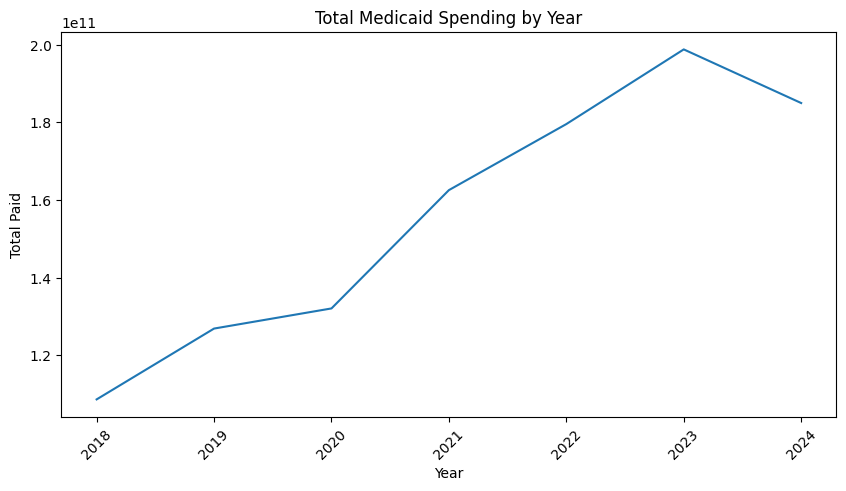

In [11]:
df = con.execute("""
    SELECT 
        SUBSTR(CLAIM_FROM_MONTH, 1, 4) AS year,
        SUM(TOTAL_PAID) AS total_spending
    FROM read_parquet(?)
    GROUP BY year
    ORDER BY year
""", [str(PARQUET_PATH)]).df()


plt.figure(figsize=(10,5))
plt.plot(df["year"], df["total_spending"])
plt.title("Total Medicaid Spending by Year")
plt.xlabel("Year")
plt.ylabel("Total Paid")
plt.xticks(rotation=45)
plt.show()


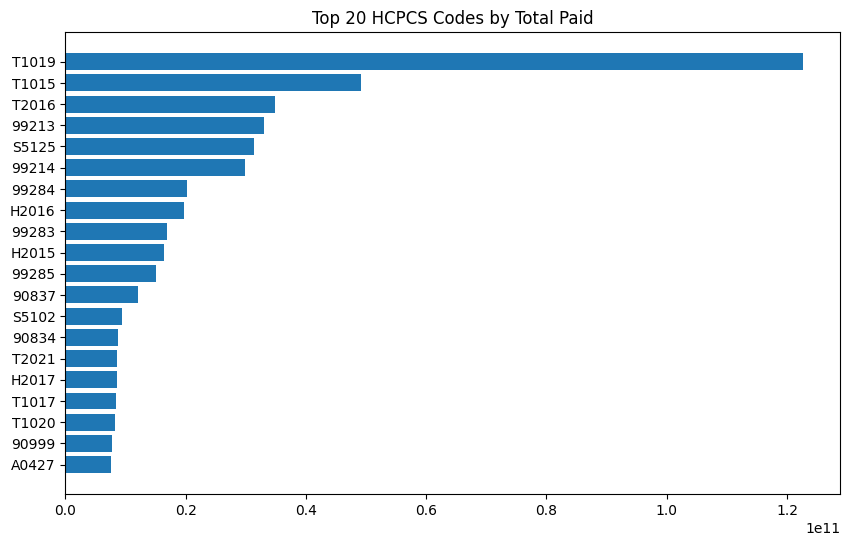

In [12]:
top_hcpcs = con.execute("""
    SELECT 
        HCPCS_CODE,
        SUM(TOTAL_PAID) AS total_paid
    FROM read_parquet(?)
    GROUP BY HCPCS_CODE
    ORDER BY total_paid DESC
    LIMIT 20
""", [str(PARQUET_PATH)]).df()

plt.figure(figsize=(10,6))
plt.barh(top_hcpcs["HCPCS_CODE"], top_hcpcs["total_paid"])
plt.title("Top 20 HCPCS Codes by Total Paid")
plt.gca().invert_yaxis()
plt.show()


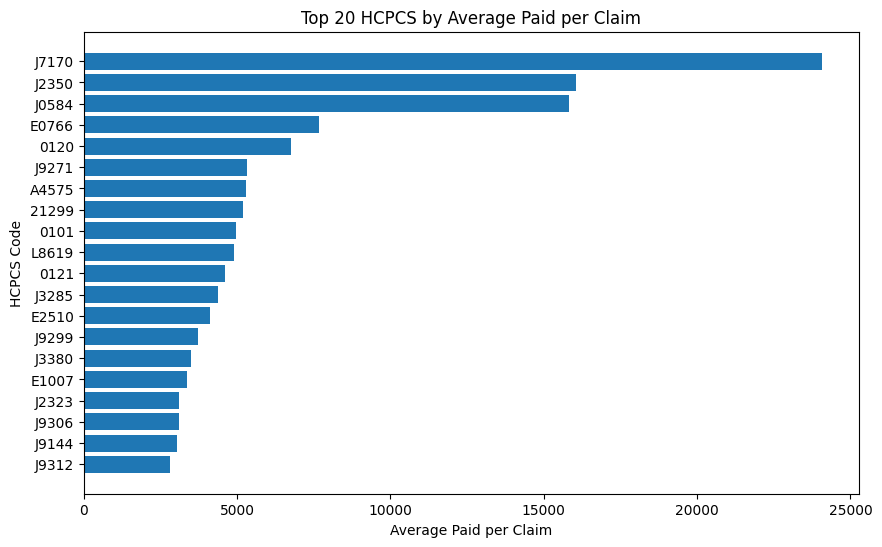

In [14]:
avg_paid = con.execute(f"""
    SELECT
        HCPCS_CODE,
        SUM(TOTAL_PAID) / SUM(TOTAL_CLAIMS) AS paid_per_claim,
        SUM(TOTAL_CLAIMS) AS total_claims
    FROM read_parquet(?)
    GROUP BY HCPCS_CODE
    HAVING SUM(TOTAL_CLAIMS) > 10000
    ORDER BY paid_per_claim DESC
    LIMIT 20
""", [str(PARQUET_PATH)]).df()

plt.figure(figsize=(10,6))
plt.barh(avg_paid["HCPCS_CODE"], avg_paid["paid_per_claim"])
plt.gca().invert_yaxis()

plt.title("Top 20 HCPCS by Average Paid per Claim")
plt.xlabel("Average Paid per Claim")
plt.ylabel("HCPCS Code")

plt.show()
